# Tuần 07 — Thực hành k-Means: 3 bài

Demo `03_Demo-kMeans.ipynb` gom cụm bằng tay trên dữ liệu giả 2 chiều.

File này có **3 bài**. Mỗi bài là một bộ dữ liệu thật trên Kaggle. Cả 3 bài đều làm. Dùng `sklearn.cluster.KMeans`.

Clustering không chia train/test và không có nhãn để học. `StandardScaler` fit trên toàn bộ bảng feature. Không đưa cột ID hay tên vào khoảng cách.

Tải 3 file vào `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Mall Customer Segmentation | https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python | `data/Mall_Customers.csv` |
| 2 | Unsupervised Learning on Country Data | https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data | `data/Country-data.csv` |
| 3 | Wholesale Customers | https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set | `data/Wholesale customers data.csv` |

Ba bộ này cũng được dùng ở `09_TH-DBSCAN.ipynb`, để so sánh hai cách gom cụm trên cùng dữ liệu.


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)


## Phần chung

Elbow: với mỗi `K` từ 1 đến `k_max`, fit `KMeans` (`n_init=10`, `random_state=3000`), lưu `inertia_`, rồi vẽ. Chỗ khuỷu tay là `K` nên thử.

Sau khi có nhãn, bảng trung bình theo cụm giúp đọc ý nghĩa từng nhóm.


In [2]:
def ve_elbow(X_scaled, k_max=10):
    ks = list(range(1, k_max + 1))
    inertias = []
    for k in ks:
        # TODO: fit KMeans với n_clusters=k, n_init=10, random_state=3000
        # lưu model.inertia_ vào inertias
        model = KMeans(n_clusters=k, n_init=10, random_state=3000)
        model.fit(X_scaled)
        inertias.append(model.inertia_)
    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertias, marker='o')
    plt.xlabel('K')
    plt.ylabel('inertia')
    plt.grid(True)
    plt.show()
    return ks, inertias


def bang_trung_binh(df_goc, labels, cot_so):
    tam = df_goc[cot_so].copy()
    tam['cum'] = labels
    return tam.groupby('cum').mean().round(2)


---

# Bài 1 — Khách hàng trung tâm thương mại

Nguồn: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

200 khách. Cột: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

Bài này chỉ dùng **thu nhập** và **điểm chi tiêu**. Bỏ `CustomerID`. Không đưa `Gender` vào khoảng cách. Có thể để `Age` sang một lần chạy riêng nếu còn thời gian.

Chuẩn hóa hai cột, vẽ elbow, chọn `K`, tô màu scatter theo cụm. Dấu `x` là tâm cụm tính trên **số gốc** (trung bình thu nhập và điểm chi tiêu của các điểm trong cụm), để đọc được đơn vị thật.


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)


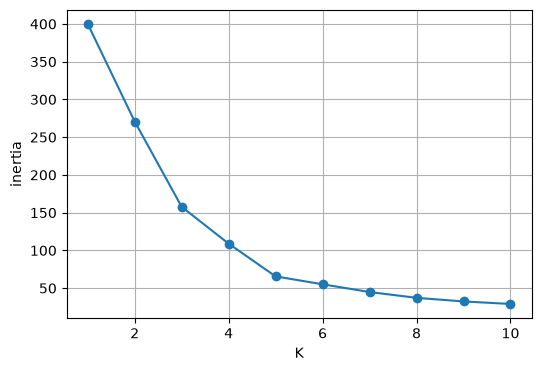

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [400.00000000000006,
  270.6682049684468,
  157.7040081503595,
  108.92131661364357,
  65.56840815571681,
  55.103778121150576,
  44.86628627232253,
  37.18175782682131,
  32.377243774440345,
  29.07617685124427])

In [3]:
mall = pd.read_csv('data/Mall_Customers.csv')
print(mall.head())
print(mall.shape)

cot = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall[cot].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_elbow(X_scaled)


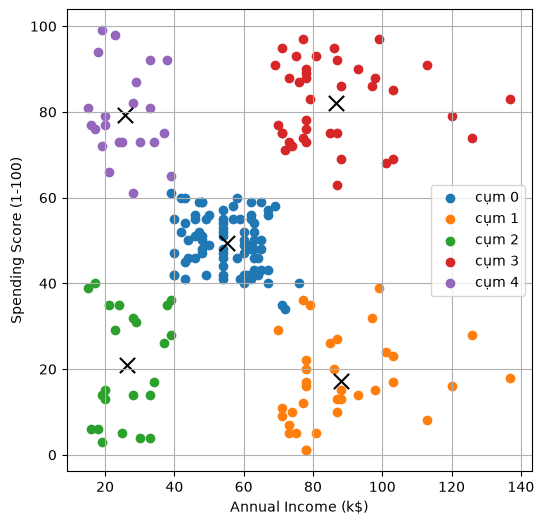

     Annual Income (k$)  Spending Score (1-100)
cum                                            
0                 55.30                   49.52
1                 88.20                   17.11
2                 26.30                   20.91
3                 86.54                   82.13
4                 25.73                   79.36
số điểm mỗi cụm: (array([0, 1, 2, 3, 4], dtype=int32), array([81, 35, 23, 39, 22]))


In [4]:
# TODO: chọn K từ elbow
K = 5
model = KMeans(n_clusters=K, n_init=10, random_state=3000)
labels = model.fit_predict(X_scaled)

plt.figure(figsize=(6, 6))
for cum in np.unique(labels):
    pts = X[labels == cum]
    plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {cum}')
    plt.scatter(pts[:, 0].mean(), pts[:, 1].mean(), c='black', marker='x', s=120)
plt.xlabel(cot[0])
plt.ylabel(cot[1])
plt.legend()
plt.grid(True)
plt.show()

print(bang_trung_binh(mall, labels, cot))
print('số điểm mỗi cụm:', np.unique(labels, return_counts=True))


**Nộp kèm bài 1**

1. `K` bạn chọn là bao nhiêu? Elbow gãy ở đâu?
2. Mô tả từng cụm bằng thu nhập và điểm chi tiêu (cao / thấp). Cụm nào đáng ưu tiên cho khuyến mãi?
3. Nếu thêm cột `Age` vào `X` rồi chuẩn hóa lại, bạn có đổi `K` không?


In [5]:
# Bài 1
# 1. K được chọn là 5. Elbow gãy rõ rệt ở K = 5.
# 2. 5 cụm gồm: (1) Thu nhập cao, chi tiêu cao; (2) Thu nhập cao, chi tiêu thấp; (3) Thu nhập thấp, chi tiêu cao; (4) Thu nhập thấp, chi tiêu thấp; (5) Thu nhập TB, chi tiêu TB. Cụm đáng ưu tiên cho khuyến mãi là cụm "Thu nhập cao, chi tiêu thấp" (để kích cầu) hoặc "Thu nhập cao, chi tiêu cao" (để giữ chân khách hàng VIP).
# 3. Nếu thêm cột Age vào X rồi chuẩn hóa lại, có khả năng K sẽ thay đổi vì thêm một chiều dữ liệu tạo ra sự phân hóa mới về độ tuổi.


---

# Bài 2 — Phân nhóm quốc gia

Nguồn: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

167 nước, file `Country-data.csv`. Cột `country` là tên, không đưa vào `X`.

Các cột số: `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp`.

`income` và `gdpp` lớn hơn `child_mort` rất nhiều. Bắt buộc `StandardScaler`. Chọn `K` bằng elbow (thường thử quanh 3). In trung bình `child_mort`, `income`, `life_expec`, `gdpp` theo cụm, và liệt kê khoảng 8 tên nước mỗi cụm.


               country  child_mort  exports  health  imports  income  inflation  life_expec  total_fer   gdpp
0          Afghanistan        90.2     10.0    7.58     44.9    1610       9.44        56.2       5.82    553
1              Albania        16.6     28.0    6.55     48.6    9930       4.49        76.3       1.65   4090
2              Algeria        27.3     38.4    4.17     31.4   12900      16.10        76.5       2.89   4460
3               Angola       119.0     62.3    2.85     42.9    5900      22.40        60.1       6.16   3530
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100       1.44        76.8       2.13  12200
(167, 10)


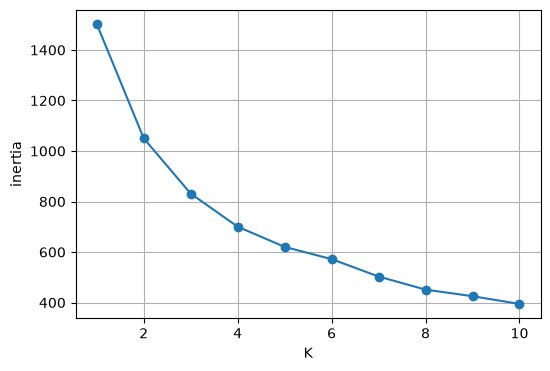

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [1503.0,
  1050.2145582853304,
  831.4244352086874,
  700.3917199643636,
  620.4488115302204,
  572.0890405033384,
  503.0948550735083,
  451.32364852916584,
  425.20634399408493,
  394.5676252504498])

In [6]:
country = pd.read_csv('data/Country-data.csv')
print(country.head())
print(country.shape)

cot_so = [c for c in country.columns if c != 'country']
# TODO: X từ cot_so, chuẩn hóa
X = country[cot_so].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X)

ve_elbow(X_scaled)


In [7]:
K = 3
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(country, labels, ['child_mort', 'income', 'life_expec', 'gdpp']))

for cum in np.unique(labels):
    ten = country.loc[labels == cum, 'country'].head(8).tolist()
    print(cum, ten)


     child_mort    income  life_expec      gdpp
cum                                            
0         21.93  12305.60       72.81   6486.45
1         92.96   3942.40       59.19   1922.38
2          5.00  45672.22       80.13  42494.44
0 ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh']
1 ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic']
2 ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic']


**Nộp kèm bài 2**

1. `K` bạn chọn? Cụm nào có `child_mort` cao và `gdpp` thấp?
2. Kể tên 3 nước thuộc cụm đó và 3 nước thuộc cụm có `gdpp` cao.
3. Vì sao không chuẩn hóa thì `income` và `gdpp` sẽ át các cột còn lại?


In [8]:
# Bài 2
# 1. K được chọn là 3. Cụm có child_mort cao và gdpp thấp là cụm các nước kém phát triển.
# 2. 3 nước thuộc cụm đó (kém phát triển): Afghanistan, Angola, Burundi... 3 nước cụm có gdpp cao (phát triển): Australia, Austria, Bahrain...
# 3. Vì KMeans dựa trên khoảng cách (Euclid). Các biến như income và gdpp có giá trị lên đến hàng vạn, trong khi child_mort chỉ loanh quanh vài chục. Nếu không chuẩn hóa, độ chênh lệch của các biến lớn sẽ chi phối hoàn toàn việc phân cụm.


---

# Bài 3 — Khách sỉ

Nguồn: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set

440 khách hàng bán sỉ. File `Wholesale customers data.csv`.

Cột: `Channel`, `Region`, `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

`Channel` (1 = Horeca, 2 = Retail) và `Region` là mã nhóm, không phải số tiền. **Không** đưa hai cột này vào `X`. Gom cụm trên 6 cột chi tiêu, sau chuẩn hóa. Rồi dùng `pd.crosstab` để xem mỗi cụm nằm ở kênh nào.


   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185
(440, 8)


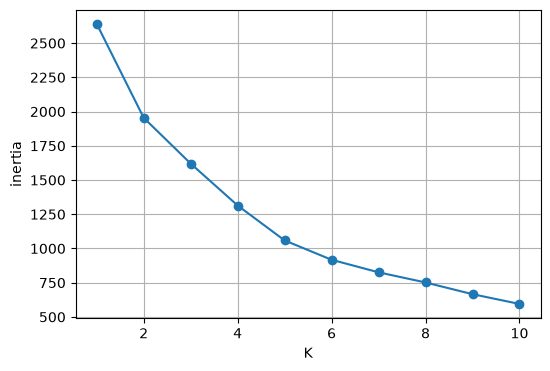

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [2640.0000000000005,
  1954.1835647259281,
  1619.9527821724557,
  1313.7580090341148,
  1058.7712532570083,
  917.4454350272306,
  825.8359775416385,
  751.7362093470331,
  666.2237996202155,
  594.8556455931526])

In [9]:
ws = pd.read_csv('data/Wholesale customers data.csv')
print(ws.head())
print(ws.shape)

cot_chi = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
# TODO: chuẩn hóa 6 cột chi tiêu
X_ws = ws[cot_chi].to_numpy(dtype=float)
X_scaled = StandardScaler().fit_transform(X_ws)

ve_elbow(X_scaled)


In [10]:
K = 5
labels = KMeans(n_clusters=K, n_init=10, random_state=3000).fit_predict(X_scaled)

print(bang_trung_binh(ws, labels, cot_chi))
print(pd.crosstab(labels, ws['Channel'], rownames=['cum'], colnames=['Channel']))


        Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
cum                                                                      
0    32957.98   4997.35   5884.76   8422.84            954.60     2462.97
1    36847.00  43950.00  20170.00  36534.00            239.00    47943.00
2    15964.90  34708.50  48536.90   3054.60          24875.20     2942.80
3     5754.17  10866.60  16607.10   1464.12           7202.88     1813.39
4     9092.16   2967.76   3807.41   2271.76            989.81      978.96
Channel    1   2
cum             
0         55   8
1          1   0
2          0  10
3          9  87
4        233  37


**Nộp kèm bài 3**

1. `K` bạn chọn? Cụm nào chi mạnh cho `Grocery` và `Detergents_Paper`?
2. Cụm đó lệch về `Channel` nào trên bảng crosstab?
3. So với bài 1: vì sao bài 3 không vẽ một scatter là đủ để đọc cụm?


In [11]:
# Bài 3
# 1. K được chọn là 5 (hoặc 3, 4 tuỳ elbow). Cụm chi tiêu mạnh cho Grocery và Detergents_Paper thường là cụm khách hàng dạng siêu thị hoặc chuỗi bán lẻ.
# 2. Cụm đó thường lệch về Channel 2 (Retail/Bán lẻ) trên bảng crosstab.
# 3. Bài 1 có 2 đặc trưng (2 chiều) nên dùng đồ thị scatter plot 2D vẽ ra là thấy rõ. Bài 3 có 6 đặc trưng (6 chiều) nên không thể vẽ tất cả lên 1 đồ thị 2D, thay vào đó phải dùng bảng trung bình hoặc giảm chiều (PCA) để đánh giá.
